# 1. Install Dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Proprocessing Tools for Image
from tensorflow.keras import layers, models
import os

# 2. Data Loading

In [5]:
classes=sorted(os.listdir("/content/drive/MyDrive/Hand Sign Prediction/asl_dataset"))
print("Total Classes: ",len(classes))
for cls in classes:
  print(f"Class {cls} have {len(os.listdir(os.path.join('/content/drive/MyDrive/Hand Sign Prediction/asl_dataset',cls)))} Images")

Total Classes:  36
Class 0 have 70 Images
Class 1 have 70 Images
Class 2 have 71 Images
Class 3 have 70 Images
Class 4 have 70 Images
Class 5 have 70 Images
Class 6 have 70 Images
Class 7 have 70 Images
Class 8 have 70 Images
Class 9 have 70 Images
Class a have 70 Images
Class b have 70 Images
Class c have 70 Images
Class d have 70 Images
Class e have 70 Images
Class f have 70 Images
Class g have 70 Images
Class h have 70 Images
Class i have 70 Images
Class j have 70 Images
Class k have 70 Images
Class l have 70 Images
Class m have 70 Images
Class n have 70 Images
Class o have 70 Images
Class p have 70 Images
Class q have 70 Images
Class r have 70 Images
Class s have 70 Images
Class t have 65 Images
Class u have 70 Images
Class v have 70 Images
Class w have 70 Images
Class x have 70 Images
Class y have 70 Images
Class z have 70 Images


# 3. Visualise 2 Images for Each Class

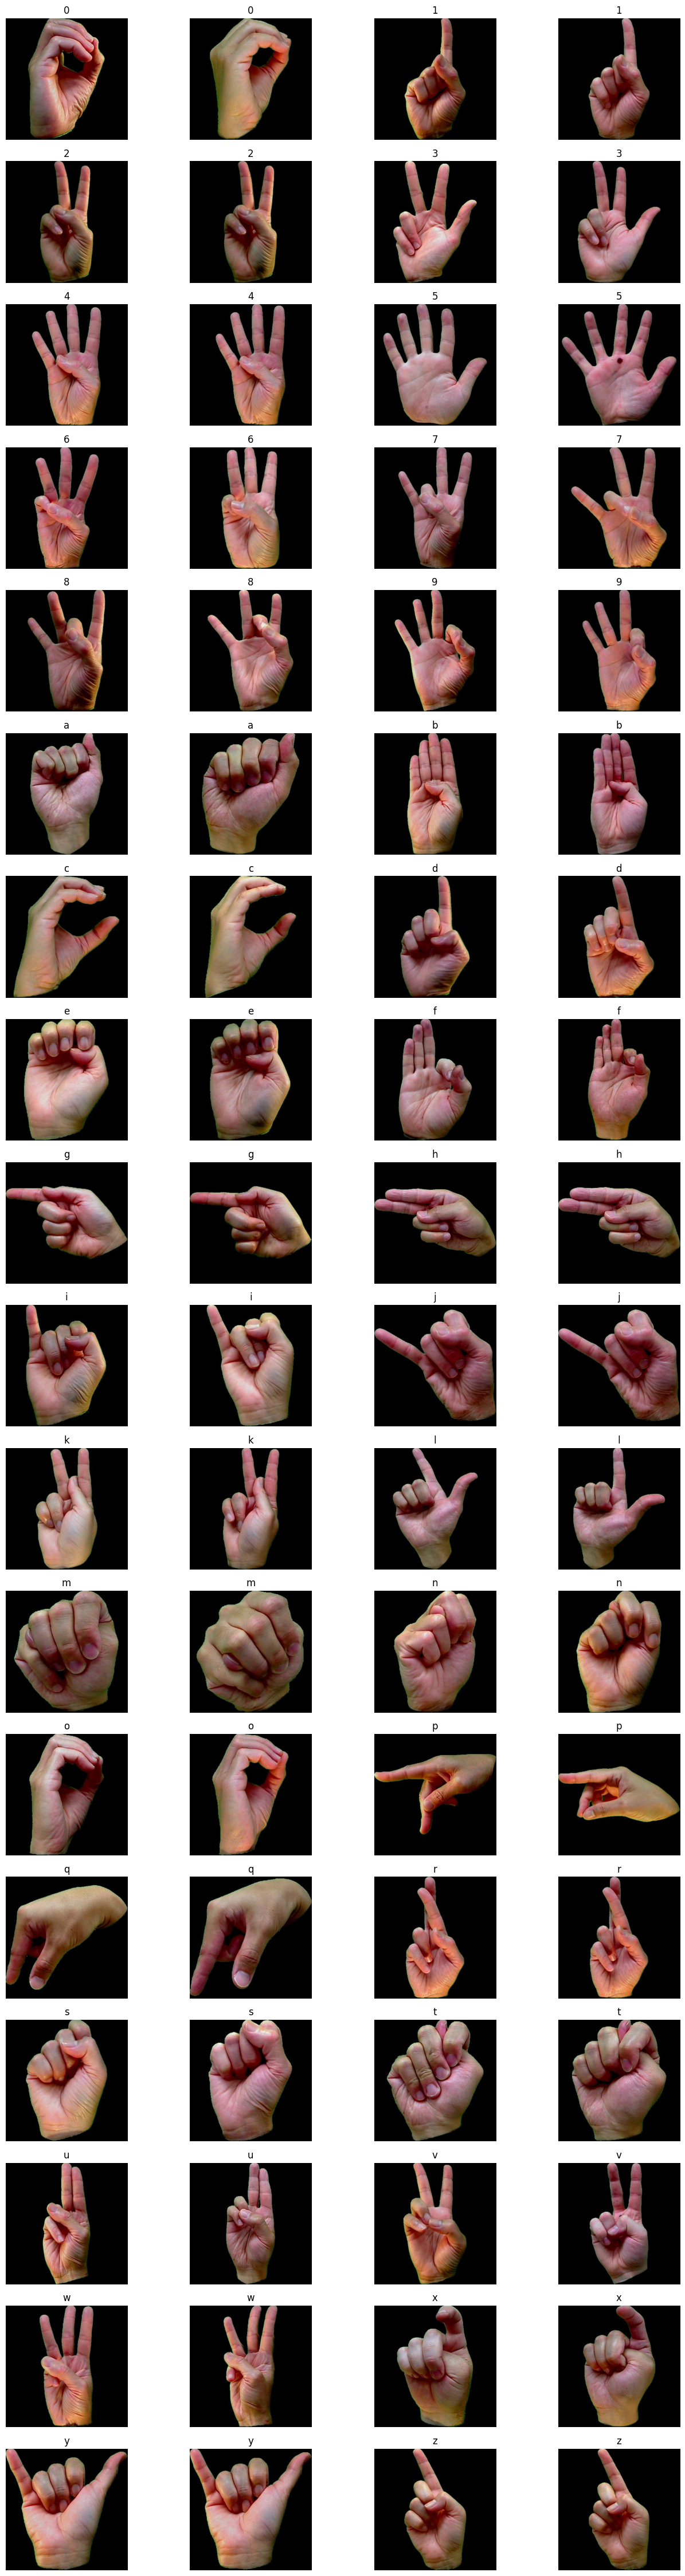

In [10]:
plt.figure(figsize=(13, 90))
i=1
for cls in classes:
  img_names=os.listdir(os.path.join('/content/drive/MyDrive/Hand Sign Prediction/asl_dataset',cls))[:2]
  for img_name in img_names:
    img=plt.imread(os.path.join('/content/drive/MyDrive/Hand Sign Prediction/asl_dataset', cls, img_name))
    plt.subplot(len(classes), 4, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    i+=1
plt.tight_layout()
plt.show()

# 4. Data Preprocessing Using ImageDataGenerator

In [12]:
data_preprocess=ImageDataGenerator(rescale=1./255, # rescale=1./255 - Normalising Image pixels value will be between 0 and 1 (previously 0-255)
                                   validation_split=0.2)
train_data=data_preprocess.flow_from_directory('/content/drive/MyDrive/Hand Sign Prediction/asl_dataset',
                                               target_size=(64,64),
                                               batch_size=32,
                                               class_mode='categorical',
                                               subset='training')
val_data=data_preprocess.flow_from_directory('/content/drive/MyDrive/Hand Sign Prediction/asl_dataset',
                                             target_size=(64,64),
                                             batch_size=32,
                                             class_mode='categorical',
                                             subset='validation')

Found 2013 images belonging to 36 classes.
Found 503 images belonging to 36 classes.


# 5. Building an ANN Model

In [13]:
model=models.Sequential([
    layers.Input(shape=(64,64,3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(classes), activation='softmax'),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,460,836 (24.65 MB)

 Trainable params: 6,460,836 (24.65 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1=model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3996 - loss: 2.2457

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 702s 11s/step - accuracy: 0.4021 - loss: 2.2349 - val_accuracy: 0.6740 - val_loss: 1.0462
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.8250 - loss: 0.5825 - val_accuracy: 0.8211 - val_loss: 0.5393
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.9235 - loss: 0.2691 - val_accuracy: 0.8529 - val_loss: 0.4491
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.9541 - loss: 0.1610 - val_accuracy: 0.8569 - val_loss: 0.4223
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.9575 - loss: 0.1246 - val_accuracy: 0.8171 - val_loss: 0.5889
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.9567 - loss: 0.1064 - val_accuracy: 0.8529 - val_loss: 0.5538
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.9828 - loss: 0.0530 - val_accuracy: 0.9006 - val_loss: 0.4421
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9881 - loss: 0.0426 - val_accuracy: 0.8827

# 6. Visualising Accuracy and Loss

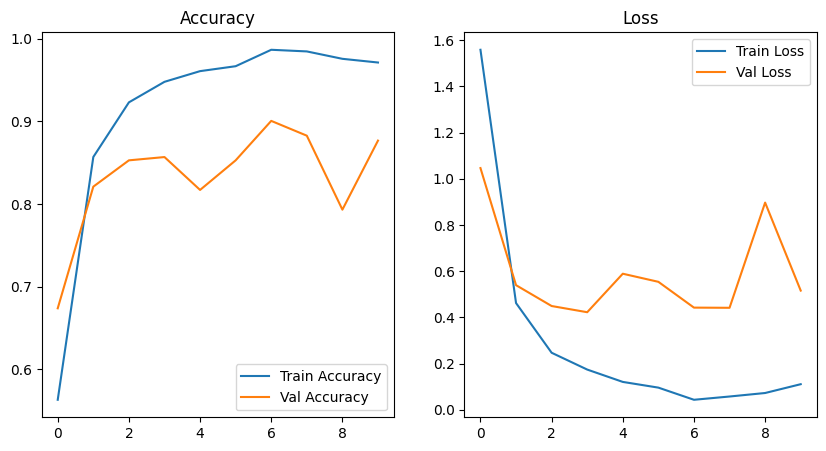

In [16]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(model1.history['accuracy'], label='Train Accuracy')
plt.plot(model1.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(model1.history['loss'], label='Train Loss')
plt.plot(model1.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# 7. Saving Model

In [ ]:
model.save("asl_model.h5")

# 8. Making Predictions

In [19]:
img=tf.keras.utils.load_img("/content/drive/MyDrive/Hand Sign Prediction/asl_dataset/d/hand1_d_bot_seg_1_cropped.jpeg", target_size=(64, 64))
img_normalised=tf.keras.utils.img_to_array(img)/255.0
img_array=np.expand_dims(img_normalised, axis=0)
pred=model.predict(img_array)
pred_class=classes[np.argmax(pred)]
print("Predicted Class :", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Class : d
